# 04. Economic Evaluation & Backtesting

**Research Question 2:** Does superior statistical accuracy translate into higher risk-adjusted
portfolio returns?

Feeds all 11 models' walk-forward vol forecasts (`data/processed/forecasts_*.csv`, 20-day horizon
— the horizon that spans a monthly rebalance) through the four portfolio strategies in
`src/backtest.py`: **Volatility-Timing** (SPY/bond), **Risk-Parity** (15-stock, inverse-vol
weighted), **Regime-Based** (discrete equity/bond allocation), and **VRP** (implied-vs-forecast
variance risk premium). 11 models × 4 strategies = 44 combinations, evaluated with
`performance_metrics()` (Sharpe, Sortino, Max Drawdown, Calmar, annualized transaction-cost drag).

All return series are **log returns** (`np.log(Close/Close.shift(1))`, matching `src/data.py`),
consistent with the log-return fix applied to `performance_metrics()` in `src/backtest.py`.

**Output:** `results/portfolio_performance.csv` (this is the file referenced in `CLAUDE.md` and
`claude-handoff.md` as the Week 8 deliverable, produced here for the first time).

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import ASSETS
from src.backtest import (
    vol_timing_strategy, risk_parity_strategy, regime_strategy, vrp_strategy,
    performance_metrics,
)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

PROCESSED = '../data/processed'
FIGDIR    = '../results/figures'
os.makedirs(FIGDIR, exist_ok=True)

INDEX_TICKERS = ['SPY', 'QQQ', 'IWM']
STOCK_TICKERS = [t for t in ASSETS if t not in INDEX_TICKERS]
print(f"Risk-parity universe (15 stocks): {STOCK_TICKERS}")

Risk-parity universe (15 stocks): ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'BAC', 'JNJ', 'UNH', 'PFE', 'AMZN', 'WMT', 'HD', 'XOM', 'CVX', 'CAT']


## Load returns and vol forecasts

Log returns for all 18 assets (matching the `src/data.py:69` convention), the IV proxy
(VIX/VXN, for the VRP strategy), and a pivoted date×ticker forecast matrix per model at the
20-day horizon (`h20` — spans the ~1-month holding period until the next rebalance, unlike
`h1`).

In [ ]:
prices = pd.read_csv(os.path.join(PROCESSED, 'prices_clean.csv'), index_col=0, parse_dates=True)
log_returns = np.log(prices / prices.shift(1))

spy_returns   = log_returns['SPY'].dropna()
stock_returns = log_returns[STOCK_TICKERS].dropna(how='all')

iv = pd.read_csv(os.path.join(PROCESSED, 'iv_monthly.csv'), index_col=0, parse_dates=True)

MODEL_FILES = {
    'GARCH(1,1)':     'forecasts_garch11.csv',
    'EGARCH(1,1)':    'forecasts_egarch.csv',
    'GJR-GARCH(1,1)': 'forecasts_gjr.csv',
    'HAR-RV':         'forecasts_harv.csv',
    'HAR-X':          'forecasts_harx.csv',
    'Persistence':    'forecasts_persistence.csv',
    'Random Forest':  'forecasts_rf.csv',
    'XGBoost':        'forecasts_xgb.csv',
    'LSTM':           'forecasts_lstm.csv',
    'GARCH-RF':       'forecasts_garch_rf.csv',
    'GARCH-XGBoost':  'forecasts_garch_xgb.csv',
}
MODEL_FAMILY = {
    'GARCH(1,1)': 'Econometric', 'EGARCH(1,1)': 'Econometric',
    'GJR-GARCH(1,1)': 'Econometric', 'HAR-RV': 'Econometric', 'HAR-X': 'Econometric',
    'Persistence': 'Naive',
    'Random Forest': 'ML', 'XGBoost': 'ML', 'LSTM': 'ML',
    'GARCH-RF': 'Hybrid', 'GARCH-XGBoost': 'Hybrid',
}

def load_forecast_pivot(model_name: str, horizon: str = 'h20') -> pd.DataFrame:
    """Date x ticker matrix of vol forecasts for one model at one horizon."""
    df = pd.read_csv(os.path.join(PROCESSED, MODEL_FILES[model_name]), parse_dates=['date'])
    return df.pivot(index='date', columns='ticker', values=horizon)

# Sanity check
_test = load_forecast_pivot('GARCH(1,1)')
print(f"Forecast pivot shape (GARCH(1,1), h20): {_test.shape}")
print(f"SPY range: {_test['SPY'].min():.1f}% – {_test['SPY'].max():.1f}%")

## Run all 36 combinations (9 models × 4 strategies)

In [3]:
records = []
vol_timing_returns = {}   # stashed for the equity-curve figure below

for model_name in MODEL_FILES:
    fc = load_forecast_pivot(model_name)
    vol_fc_spy = fc['SPY'].dropna()

    # --- 1. Volatility-Timing (SPY/bond) ---
    res = vol_timing_strategy(spy_returns, vol_fc_spy)
    strat_ret = res['strategy'].dropna()
    vol_timing_returns[model_name] = strat_ret
    m = performance_metrics(strat_ret, cost_drag=res['cost_drag'])
    m.update({'Strategy': 'Vol-Timing', 'Model': model_name})
    records.append(m)

    # --- 2. Risk-Parity (15-stock, inverse-vol weighted) ---
    vol_fc_stocks = fc[STOCK_TICKERS]
    res = risk_parity_strategy(stock_returns, vol_fc_stocks)
    strat_ret = res['strategy'].dropna()
    m = performance_metrics(strat_ret, cost_drag=res['cost_drag'])
    m.update({'Strategy': 'Risk-Parity', 'Model': model_name})
    records.append(m)

    # --- 3. Regime-Based (discrete equity/bond allocation) ---
    res = regime_strategy(spy_returns, vol_fc_spy)
    strat_ret = res['strategy'].dropna()
    m = performance_metrics(strat_ret, cost_drag=res['cost_drag'])
    m.update({'Strategy': 'Regime-Based', 'Model': model_name})
    records.append(m)

    # --- 4. VRP (implied vs. forecast variance risk premium) ---
    res = vrp_strategy(spy_returns, vol_fc_spy, iv['SPY'].dropna())
    strat_ret = res['strategy'].dropna()
    m = performance_metrics(strat_ret, cost_drag=res['cost_drag'])
    m.update({'Strategy': 'VRP', 'Model': model_name})
    records.append(m)

results_df = pd.DataFrame(records)
print(f"{len(results_df)} model x strategy combinations computed.")

36 model x strategy combinations computed.


## Benchmarks + save `results/portfolio_performance.csv`

Buy & Hold SPY and a static equal-weight 15-stock portfolio, for reference — no rebalancing
trades, so no transaction-cost drag applies to either.

In [4]:
bench_records = []

m_bh = performance_metrics(spy_returns)
m_bh.update({'Strategy': 'Benchmark', 'Model': 'Buy & Hold SPY'})
bench_records.append(m_bh)

equal_weight_returns = stock_returns.mean(axis=1).dropna()
m_ew = performance_metrics(equal_weight_returns)
m_ew.update({'Strategy': 'Benchmark', 'Model': 'Equal-Weight 15-Stock'})
bench_records.append(m_ew)

full_df = pd.concat([results_df, pd.DataFrame(bench_records)], ignore_index=True)

COL_ORDER = ['Strategy', 'Model', 'Ann. Return', 'Ann. Volatility', 'Sharpe',
            'Sortino', 'Max Drawdown', 'Calmar', 'Ann. Cost Drag']
full_df = full_df[COL_ORDER].round(4)

full_df.to_csv('../results/portfolio_performance.csv', index=False)
print(f"Saved {len(full_df)} rows → ../results/portfolio_performance.csv\n")

print("=== Sharpe ratio by strategy (sorted within each) ===")
for strat in ['Vol-Timing', 'Risk-Parity', 'Regime-Based', 'VRP']:
    sub = full_df[full_df['Strategy'] == strat].sort_values('Sharpe', ascending=False)
    print(f"\n{strat}:")
    print(sub[['Model', 'Sharpe', 'Ann. Return', 'Max Drawdown']].to_string(index=False))

print("\nBenchmarks:")
print(full_df[full_df['Strategy'] == 'Benchmark'][['Model', 'Sharpe', 'Ann. Return', 'Max Drawdown']].to_string(index=False))

Saved 38 rows → ../results/portfolio_performance.csv

=== Sharpe ratio by strategy (sorted within each) ===

Vol-Timing:
         Model  Sharpe  Ann. Return  Max Drawdown
          LSTM  0.4942       0.1274       -0.2729
GJR-GARCH(1,1)  0.4848       0.1188       -0.2191
 Random Forest  0.4843       0.1256       -0.2664
       XGBoost  0.4831       0.1264       -0.2775
    GARCH(1,1)  0.4823       0.1161       -0.2255
 GARCH-XGBoost  0.4411       0.1163       -0.2694
   EGARCH(1,1)  0.4389       0.1093       -0.2653
      GARCH-RF  0.3901       0.1012       -0.2554
        HAR-RV  0.3744       0.0983       -0.2325

Risk-Parity:
         Model  Sharpe  Ann. Return  Max Drawdown
 GARCH-XGBoost  0.2424       0.0723       -0.3153
      GARCH-RF  0.2384       0.0718       -0.3188
GJR-GARCH(1,1)  0.2156       0.0688       -0.3147
 Random Forest  0.2154       0.0687       -0.3227
          LSTM  0.2134       0.0685       -0.3260
    GARCH(1,1)  0.2127       0.0685       -0.3191
       XGBoost 

## Figure 9a — Sharpe ratio by model and strategy

9 models exceeds a comfortable categorical color count, so color encodes **model family**
(Econometric / ML / Hybrid — 3 categories) rather than individual model identity; each
model's name is still directly readable as the bar's axis label. Faceted into one panel per
strategy rather than cramming all 4 strategies onto one axis.

In [ ]:
# Validated 3-hue categorical palette (blue/orange/violet — see dataviz skill,
# node scripts/validate_palette.js "#2a78d6,#eb6834,#4a3aa7" --mode light --pairs all => ALL PASS)
# 'Naive' (Persistence) uses a neutral gray -- it's a reference floor, not a competing
# modeling family, so it's deliberately not part of the validated 3-hue categorical set.
FAMILY_COLORS = {'Econometric': '#2a78d6', 'ML': '#eb6834', 'Hybrid': '#4a3aa7', 'Naive': '#7f7f7f'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Figure 9a: Risk-Adjusted Returns by Model and Strategy (Sharpe Ratio)',
             fontsize=13, fontweight='bold')

for ax, strat in zip(axes.flat, ['Vol-Timing', 'Risk-Parity', 'Regime-Based', 'VRP']):
    sub = results_df[results_df['Strategy'] == strat].sort_values('Sharpe')
    colors = [FAMILY_COLORS[MODEL_FAMILY[m]] for m in sub['Model']]
    ax.barh(sub['Model'], sub['Sharpe'], color=colors, edgecolor='white', lw=0.5)
    ax.axvline(0, color='#333333', lw=0.8)
    for y, val in enumerate(sub['Sharpe']):
        ax.text(val + (0.05 if val >= 0 else -0.05), y, f'{val:.2f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax.set_title(strat, fontsize=11, fontweight='bold', loc='left')
    ax.set_xlabel('Sharpe Ratio')
    ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_patches = [Patch(fc=c, label=l) for l, c in FAMILY_COLORS.items()]
fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(0.995, 0.965),
          fontsize=9, framealpha=0.9, ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.97])
path = os.path.join(FIGDIR, 'fig9a_sharpe_by_strategy.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## Figure 9b — Volatility-Timing equity curves by model

Same two-panel small-multiples convention as Figure 7 in `03_ml_models.ipynb` (facet by model
family rather than color-encoding 9 series in one axis). Colors extend that notebook's existing
per-model palette to the 5 models not yet assigned one (EGARCH, LSTM, GARCH-RF, GARCH-XGBoost).

In [ ]:
STYLE = {
    'GARCH(1,1)':     '#1f77b4',
    'EGARCH(1,1)':    '#5fa2dc',
    'GJR-GARCH(1,1)': '#aec7e8',
    'HAR-RV':         '#9467bd',
    'HAR-X':          '#8c564b',
    'Random Forest':  '#d62728',
    'XGBoost':        '#ff9896',
    'LSTM':           '#ff7f0e',
    'GARCH-RF':       '#2ca02c',
    'GARCH-XGBoost':  '#98df8a',
}
ECON_MODELS      = ['GARCH(1,1)', 'EGARCH(1,1)', 'GJR-GARCH(1,1)', 'HAR-RV', 'HAR-X']
ML_HYBRID_MODELS = ['Random Forest', 'XGBoost', 'LSTM', 'GARCH-RF', 'GARCH-XGBoost']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Figure 9b: Volatility-Timing Strategy — Equity Curves by Model (2018–2025)',
             fontsize=13, fontweight='bold')

# Rebase the SPY benchmark to the same start date as the strategies (first vol-timing
# date, ~2018) so both compound from 1.0 over the same window -- comparing against the
# full 2010-2025 buy-and-hold curve would unfairly credit SPY with 2010-2017 growth the
# strategies never had a chance to earn.
_common_start = min(r.index.min() for r in vol_timing_returns.values())
bench_equity = np.exp(spy_returns.loc[_common_start:].cumsum())

ax = axes[0]
ax.plot(bench_equity.index, bench_equity, color='black', lw=1.2, alpha=0.6, label='Buy & Hold SPY')
for name in ECON_MODELS:
    eq = np.exp(vol_timing_returns[name].cumsum())
    ax.plot(eq.index, eq, color=STYLE[name], lw=1.5, label=name)
ax.set_title('A. Traditional Econometric Models', loc='left', fontsize=11, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(bench_equity.index, bench_equity, color='black', lw=1.2, alpha=0.6, label='Buy & Hold SPY')
for name in ML_HYBRID_MODELS:
    eq = np.exp(vol_timing_returns[name].cumsum())
    ax.plot(eq.index, eq, color=STYLE[name], lw=1.5, label=name)
ax.set_title('B. Machine Learning & Hybrid Models', loc='left', fontsize=11, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Year')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig9b_vol_timing_equity_curves.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

# Week 9 — Robustness & Extensions

## Cross-asset validation

Week 7's statistical accuracy table (`results/forecast_accuracy_all_models.csv`) reported only
the **cross-asset mean** RMSE per model. That can hide a lot: "Random Forest is best at h1" could
be true on average while actually failing on half the individual assets. This section builds the
full 9-model × 18-asset RMSE (h1) matrix and visualizes it as a heatmap to check whether the
Week 7 ranking holds asset-by-asset.

Color here is a pure magnitude job (low error → high error, no identity/categorical dimension),
so it uses a single-hue sequential ramp (lightest = lowest RMSE = best) rather than the
model-family categorical palette used in Figures 9a/9b.

In [7]:
from src.evaluation import evaluate_forecasts

rmse_matrix = pd.DataFrame(index=list(MODEL_FILES.keys()), columns=ASSETS, dtype=float)

for model_name, fname in MODEL_FILES.items():
    df_m = pd.read_csv(os.path.join(PROCESSED, fname), parse_dates=['date'])
    for ticker in ASSETS:
        sub = df_m[df_m['ticker'] == ticker].dropna(subset=['h1', 'rv_h1'])
        if len(sub) < 5:
            continue
        row = evaluate_forecasts(sub['rv_h1'], {model_name: sub['h1'].values})
        rmse_matrix.loc[model_name, ticker] = row.loc[model_name, 'RMSE']

# Order rows by cross-asset mean RMSE (best model first) for a readable heatmap
rmse_matrix = rmse_matrix.loc[rmse_matrix.mean(axis=1).sort_values().index]
rmse_matrix.to_csv('../results/cross_asset_rmse_h1.csv')

best_model_per_asset = rmse_matrix.idxmin(axis=0)
print("=== Best model per asset (lowest h1 RMSE) ===")
print(best_model_per_asset.value_counts().to_string())
print(f"\nRandom Forest is best on {(best_model_per_asset == 'Random Forest').sum()}/18 assets"
      f" (cross-asset mean ranking said it was #1 overall).")

=== Best model per asset (lowest h1 RMSE) ===
Random Forest    18

Random Forest is best on 18/18 assets (cross-asset mean ranking said it was #1 overall).


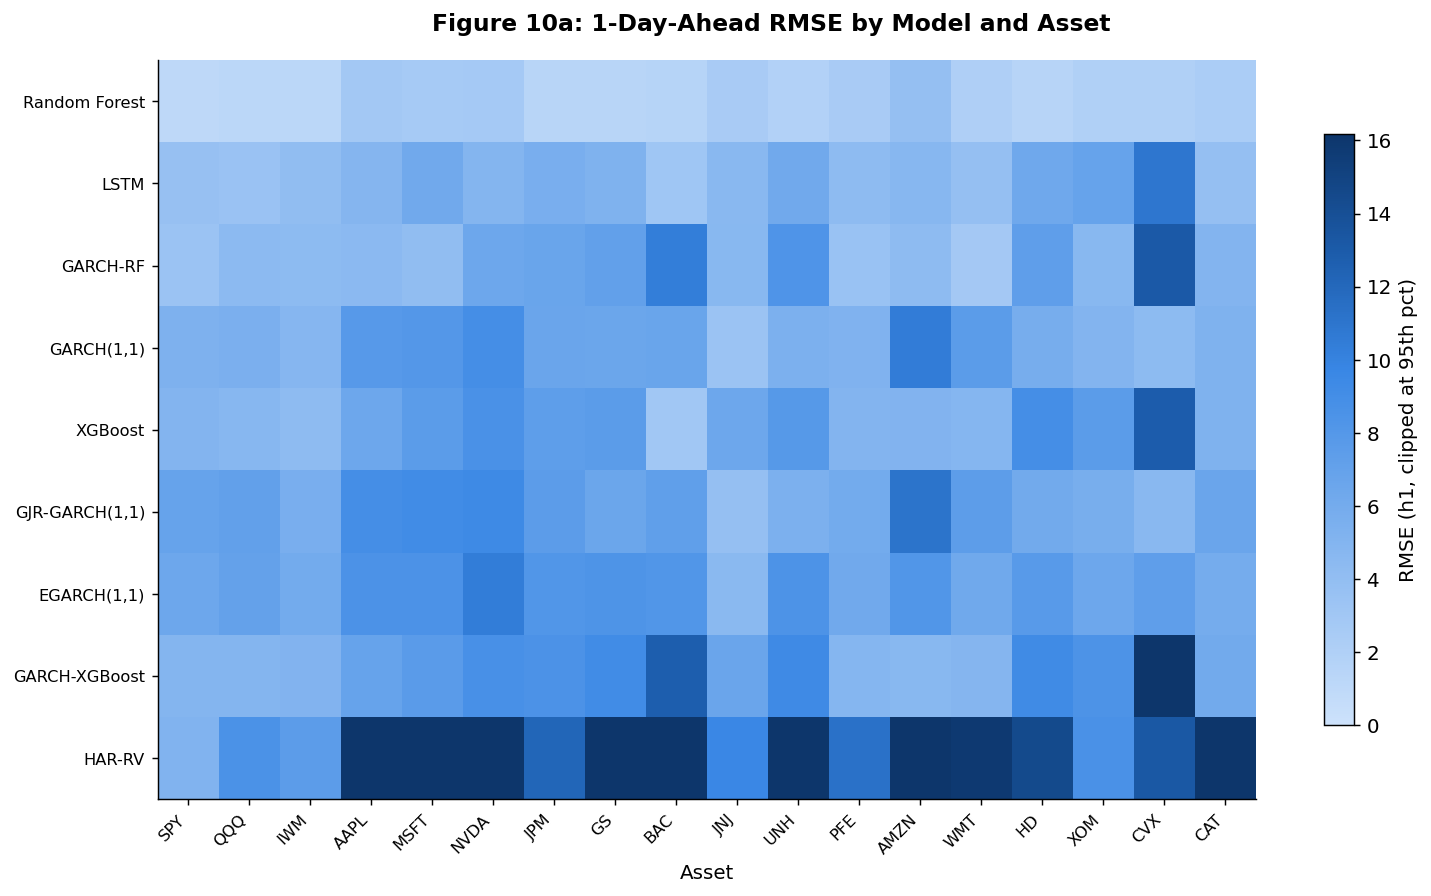

Saved → ../results/figures/fig10a_cross_asset_rmse_heatmap.png


In [8]:
from matplotlib.colors import LinearSegmentedColormap

# Validated sequential blue ramp (steps 100->700, dataviz skill reference palette.md),
# used as-is rather than a generic matplotlib colormap. Lightest = lowest RMSE = best.
BLUE_RAMP = LinearSegmentedColormap.from_list('blue_seq', [
    '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#1c5cab', '#0d366b',
])

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Figure 10a: 1-Day-Ahead RMSE by Model and Asset', fontsize=13, fontweight='bold')

# Clip color scale at the 95th percentile so a few high-vol outlier assets (e.g. HAR-RV
# on NVDA) don't wash out the contrast among the rest of the grid.
vmax = np.nanpercentile(rmse_matrix.values, 95)
im = ax.imshow(rmse_matrix.values, cmap=BLUE_RAMP, aspect='auto', vmin=0, vmax=vmax)

ax.set_xticks(range(len(rmse_matrix.columns)))
ax.set_xticklabels(rmse_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(rmse_matrix.index)))
ax.set_yticklabels(rmse_matrix.index, fontsize=9)
ax.set_xlabel('Asset')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('RMSE (h1, clipped at 95th pct)')

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig10a_cross_asset_rmse_heatmap.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## Sensitivity analysis

How much of the Vol-Timing strategy's Sharpe depends on the specific `cost_per_trade` and
`max_leverage` choices baked into `src/backtest.py`'s defaults ($5/trade, 1.5x cap)? Sweeps use
the existing parameters on `vol_timing_strategy` directly — no new backtest logic. Run for
Random Forest (best statistical accuracy) and GARCH(1,1) (baseline) so the sensitivity check
itself isn't dependent on a single model.

In [9]:
SENSITIVITY_MODELS = ['Random Forest', 'GARCH(1,1)']
COST_GRID = [0, 5, 10, 20, 50]
LEVERAGE_GRID = [1.0, 1.25, 1.5, 2.0, 3.0]

sensitivity_records = []
for model_name in SENSITIVITY_MODELS:
    vol_fc_spy = load_forecast_pivot(model_name)['SPY'].dropna()
    for cost in COST_GRID:
        for lev in LEVERAGE_GRID:
            res = vol_timing_strategy(spy_returns, vol_fc_spy, max_leverage=lev, cost_per_trade=cost)
            strat_ret = res['strategy'].dropna()
            m = performance_metrics(strat_ret, cost_drag=res['cost_drag'])
            sensitivity_records.append({
                'Model': model_name, 'Cost ($/trade)': cost, 'Max Leverage': lev,
                'Sharpe': m['Sharpe'], 'Ann. Return': m['Ann. Return'],
            })

sensitivity_df = pd.DataFrame(sensitivity_records)
sensitivity_df.to_csv('../results/sensitivity_analysis.csv', index=False)

print("=== Vol-Timing Sharpe sensitivity: Random Forest ===")
pivot_rf = sensitivity_df[sensitivity_df['Model'] == 'Random Forest'].pivot(
    index='Cost ($/trade)', columns='Max Leverage', values='Sharpe').round(3)
print(pivot_rf.to_string())

print("\n=== Vol-Timing Sharpe sensitivity: GARCH(1,1) ===")
pivot_garch = sensitivity_df[sensitivity_df['Model'] == 'GARCH(1,1)'].pivot(
    index='Cost ($/trade)', columns='Max Leverage', values='Sharpe').round(3)
print(pivot_garch.to_string())

# Separate target_vol sweep (fixed at default cost/leverage)
TARGET_VOL_GRID = [10, 15, 20, 25]
tv_records = []
for model_name in SENSITIVITY_MODELS:
    vol_fc_spy = load_forecast_pivot(model_name)['SPY'].dropna()
    for tv in TARGET_VOL_GRID:
        res = vol_timing_strategy(spy_returns, vol_fc_spy, target_vol=tv)
        strat_ret = res['strategy'].dropna()
        m = performance_metrics(strat_ret, cost_drag=res['cost_drag'])
        tv_records.append({'Model': model_name, 'Target Vol (%)': tv, 'Sharpe': m['Sharpe'],
                           'Ann. Return': m['Ann. Return'], 'Ann. Volatility': m['Ann. Volatility']})

tv_df = pd.DataFrame(tv_records)
print("\n=== Vol-Timing Sharpe sensitivity to target_vol ===")
print(tv_df.round(3).to_string(index=False))

=== Vol-Timing Sharpe sensitivity: Random Forest ===
Max Leverage     1.00   1.25   1.50   2.00   3.00
Cost ($/trade)                                   
0               0.466  0.498  0.493  0.443  0.418
5               0.462  0.492  0.484  0.431  0.405
10              0.458  0.485  0.475  0.419  0.392
20              0.450  0.473  0.457  0.395  0.366
50              0.426  0.435  0.403  0.323  0.289

=== Vol-Timing Sharpe sensitivity: GARCH(1,1) ===
Max Leverage     1.00   1.25   1.50   2.00   3.00
Cost ($/trade)                                   
0               0.493  0.487  0.488  0.488  0.488
5               0.489  0.482  0.482  0.482  0.482
10              0.485  0.477  0.477  0.477  0.477
20              0.478  0.466  0.466  0.466  0.466
50              0.456  0.434  0.434  0.434  0.434

=== Vol-Timing Sharpe sensitivity to target_vol ===
        Model  Target Vol (%)  Sharpe  Ann. Return  Ann. Volatility
Random Forest              10   0.315        0.081            0.131
Random 

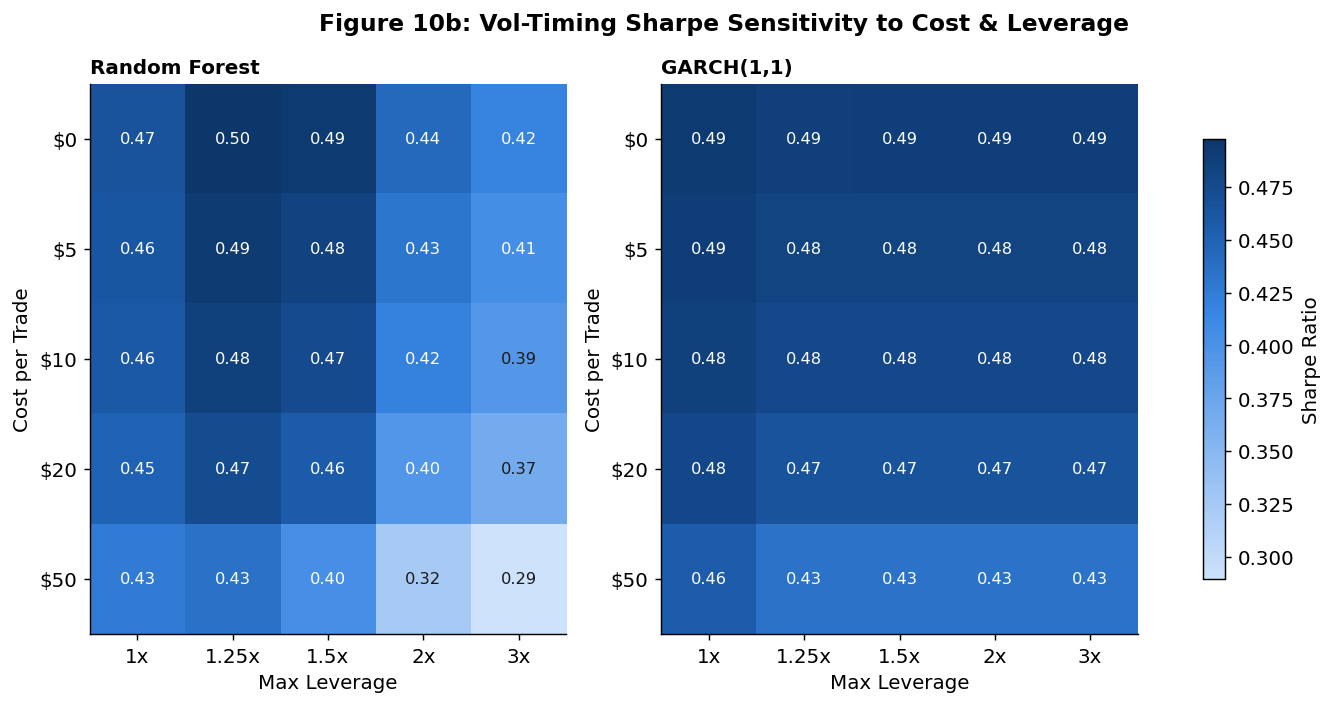

Saved → ../results/figures/fig10b_sensitivity_heatmap.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Figure 10b: Vol-Timing Sharpe Sensitivity to Cost & Leverage',
             fontsize=13, fontweight='bold')

vmin = sensitivity_df['Sharpe'].min()
vmax = sensitivity_df['Sharpe'].max()

for ax, (model_name, pivot) in zip(axes, [('Random Forest', pivot_rf), ('GARCH(1,1)', pivot_garch)]):
    im = ax.imshow(pivot.values, cmap=BLUE_RAMP, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{c:g}x' for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'${c:g}' for c in pivot.index])
    ax.set_xlabel('Max Leverage')
    ax.set_ylabel('Cost per Trade')
    ax.set_title(model_name, fontsize=11, fontweight='bold', loc='left')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            text_color = 'white' if val > (vmin + vmax) / 2 else '#1a1a1a'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=text_color)

fig.colorbar(im, ax=axes, shrink=0.8, label='Sharpe Ratio')

path = os.path.join(FIGDIR, 'fig10b_sensitivity_heatmap.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## Out-of-sample stability

The two strongest strategies (VRP and Regime-Based) both beat Buy & Hold SPY on Sharpe. Is that
edge stable across the 8-year test window, or is it concentrated in one sub-period — e.g. is
VRP's ~2-3 Sharpe just a 2022 vol-spike artifact? Split Jan 2018–Dec 2025 into two four-year
halves (pre/post-COVID: 2018–2021 vs. 2022–2025) and recompute `performance_metrics` per
sub-period, per model, for both strategies.

In [11]:
SUB_PERIODS = {
    '2018-2021': ('2018-01-01', '2021-12-31'),
    '2022-2025': ('2022-01-01', '2025-12-31'),
}

stability_records = []
for model_name in MODEL_FILES:
    vol_fc_spy = load_forecast_pivot(model_name)['SPY'].dropna()

    regime_ret = regime_strategy(spy_returns, vol_fc_spy)['strategy']
    vrp_ret = vrp_strategy(spy_returns, vol_fc_spy, iv['SPY'].dropna())['strategy']

    for period_label, (start, end) in SUB_PERIODS.items():
        for strat_name, ret_series in [('Regime-Based', regime_ret), ('VRP', vrp_ret)]:
            sub_ret = ret_series.loc[start:end].dropna()
            if len(sub_ret) < 30:
                continue
            m = performance_metrics(sub_ret)
            stability_records.append({
                'Model': model_name, 'Strategy': strat_name, 'Period': period_label,
                'Sharpe': m['Sharpe'], 'Ann. Return': m['Ann. Return'],
            })

stability_df = pd.DataFrame(stability_records)
stability_df.to_csv('../results/stability_by_period.csv', index=False)

for strat_name in ['Regime-Based', 'VRP']:
    print(f"=== {strat_name}: Sharpe by sub-period ===")
    piv = stability_df[stability_df['Strategy'] == strat_name].pivot(
        index='Model', columns='Period', values='Sharpe').round(3)
    piv['Sign flip?'] = (piv['2018-2021'] > 0) != (piv['2022-2025'] > 0)
    print(piv.to_string())
    print()

=== Regime-Based: Sharpe by sub-period ===
Period          2018-2021  2022-2025  Sign flip?
Model                                           
EGARCH(1,1)         0.606      0.580       False
GARCH(1,1)          0.759      0.544       False
GARCH-RF            0.573      0.833       False
GARCH-XGBoost       0.487      0.616       False
GJR-GARCH(1,1)      0.715      0.563       False
HAR-RV              0.624      0.722       False
LSTM                0.792      0.576       False
Random Forest       0.559      0.625       False
XGBoost             0.531      0.506       False

=== VRP: Sharpe by sub-period ===
Period          2018-2021  2022-2025  Sign flip?
Model                                           
EGARCH(1,1)         3.099      2.555       False
GARCH(1,1)          5.136      3.401       False
GARCH-RF            3.060      2.950       False
GARCH-XGBoost       4.568      5.281       False
GJR-GARCH(1,1)      6.692      4.365       False
HAR-RV              3.585      2.434    

## Cost-benefit synthesis

Ties together the computational cost of each model (walk-forward wall-clock time), its
statistical gain (RMSE and Model Confidence Set inclusion from Week 7), and its economic gain
(best Sharpe across the four strategies from `results/portfolio_performance.csv`, and the
improvement over the GARCH(1,1) baseline within the same strategy). Wall-clock figures for LSTM,
GARCH-RF, and GARCH-XGBoost are exact, taken directly from `run_walk_forward.log`. The
econometric family and the standalone RF/XGBoost runs were not separately timed per model
(`02_garch_baseline.ipynb`'s own estimate is ~15–25 min combined for all 4 econometric models ×
18 assets) — reported as a qualitative tier rather than a fabricated precise number.

In [ ]:
# Compute-cost proxy. Exact figures (seconds, from run_walk_forward.log) where measured;
# qualitative tier otherwise -- no fabricated precision for the untimed runs.
COMPUTE_COST = {
    'GARCH(1,1)':     {'tier': 'Low (secs-min, part of ~15-25min/4 models combined)', 'seconds': np.nan},
    'EGARCH(1,1)':    {'tier': 'Low (secs-min, part of ~15-25min/4 models combined)', 'seconds': np.nan},
    'GJR-GARCH(1,1)': {'tier': 'Low (secs-min, part of ~15-25min/4 models combined)', 'seconds': np.nan},
    'HAR-RV':         {'tier': 'Very Low (OLS, negligible)', 'seconds': np.nan},
    'HAR-X':          {'tier': 'Very Low (OLS, negligible)', 'seconds': np.nan},
    'Persistence':    {'tier': 'Negligible (no fitting)', 'seconds': 0.0},
    'Random Forest':  {'tier': 'Low-Medium (not separately timed)', 'seconds': np.nan},
    'XGBoost':        {'tier': 'Low-Medium (not separately timed)', 'seconds': np.nan},
    'LSTM':           {'tier': 'Very High', 'seconds': 86864},
    'GARCH-RF':       {'tier': 'Medium', 'seconds': 1005},
    'GARCH-XGBoost':  {'tier': 'Low', 'seconds': 61},
}

rmse_all = pd.read_csv('../results/forecast_accuracy_all_models.csv', index_col=0)
mcs = pd.read_csv('../results/model_confidence_set.csv', index_col=0)

synthesis_rows = []
for model_name in MODEL_FILES:
    rmse_h1 = rmse_all.loc[model_name, 'RMSE'] if model_name in rmse_all.index else np.nan
    in_mcs = bool(mcs.loc[model_name, 'in_mcs']) if model_name in mcs.index else False

    model_rows = results_df[results_df['Model'] == model_name]
    best_row = model_rows.loc[model_rows['Sharpe'].idxmax()]

    garch_sharpe_same_strategy = results_df[
        (results_df['Model'] == 'GARCH(1,1)') & (results_df['Strategy'] == best_row['Strategy'])
    ]['Sharpe'].iloc[0]

    cost = COMPUTE_COST[model_name]
    synthesis_rows.append({
        'Model': model_name,
        'Compute Cost': cost['tier'],
        'Wall-clock (s)': cost['seconds'],
        'RMSE (h1)': round(rmse_h1, 3) if pd.notna(rmse_h1) else np.nan,
        'In 90% MCS?': in_mcs,
        'Best Strategy': best_row['Strategy'],
        'Best Sharpe': round(best_row['Sharpe'], 3),
        'vs. GARCH(1,1) (same strategy)': round(best_row['Sharpe'] - garch_sharpe_same_strategy, 3),
    })

synthesis_df = pd.DataFrame(synthesis_rows).sort_values('Best Sharpe', ascending=False)
synthesis_df.to_csv('../results/cost_benefit_synthesis.csv', index=False)
print("=== Cost-Benefit Synthesis ===")
print(synthesis_df.to_string(index=False))